In [32]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale = 1.0/255,
    horizontal_flip = True,
    rotation_range = 15,
    zoom_range = 0.10,
    width_shift_range = 0.10,
    height_shift_range = 0.1
)

val_datagen = ImageDataGenerator(
    rescale = 1.0/255
)

In [33]:
train = train_datagen.flow_from_directory(
    'dataset/train',
    target_size = (64, 64),
    batch_size = 32,
    class_mode = 'binary',
    shuffle = True
)
val = train_datagen.flow_from_directory(
    'dataset/val',
    target_size = (64, 64),
    batch_size = 32,
    class_mode = 'binary',
    shuffle = False
)

Found 402 images belonging to 2 classes.
Found 102 images belonging to 2 classes.


In [34]:
from tensorflow.keras.applications import MobileNetV2, VGG16, ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

base_model = ResNet50(
    weights='imagenet',
    include_top=False,  
    input_shape=(64, 64, 3)
)

base_model.trainable = False

In [35]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

In [36]:
model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [37]:
model.fit(train, epochs=10, validation_data=val)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 435ms/step - accuracy: 0.4950 - loss: 0.7179 - val_accuracy: 0.5490 - val_loss: 0.6902
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 174ms/step - accuracy: 0.5522 - loss: 0.6898 - val_accuracy: 0.5000 - val_loss: 0.7045
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 173ms/step - accuracy: 0.4975 - loss: 0.7235 - val_accuracy: 0.5000 - val_loss: 0.7140
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 172ms/step - accuracy: 0.5174 - loss: 0.7082 - val_accuracy: 0.5392 - val_loss: 0.6910
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 171ms/step - accuracy: 0.5498 - loss: 0.6903 - val_accuracy: 0.5196 - val_loss: 0.6870
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 173ms/step - accuracy: 0.5348 - loss: 0.6899 - val_accuracy: 0.5882 - val_loss: 0.6839
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 169ms/step - accuracy: 0.5274 - loss: 0.6942 - val_accuracy: 0.5196 - val_loss: 0.6923
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 170ms/step - accuracy: 0.5373 - loss: 0.6907 - val_accuracy: 0

In [38]:
model.evaluate(val)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - accuracy: 0.5588 - loss: 0.6881


[0.6881120800971985, 0.5588235259056091]

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Dog


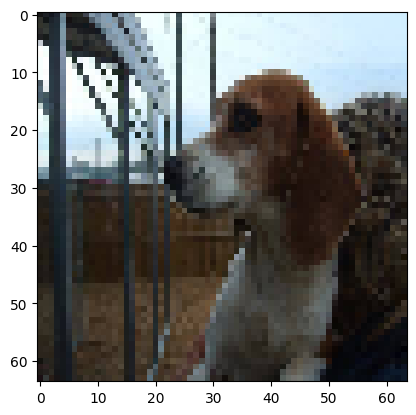

In [39]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

path = 'cat_dog_dataset/val/dogs/dog.465.jpg'
img = load_img(path, target_size=(64,64))
img_array = img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

pred = model.predict(img_array)
if pred[0][0] > 0.5:
    print("Dog")
else:
    print("Cat")

plt.imshow(img)
plt.show()